## Problem Statement 

You need to build a model that is able to classify customer complaints based on the products/services. By doing so, you can segregate these tickets into their relevant categories and, therefore, help in the quick resolution of the issue.

You will be doing topic modelling on the <b>.json</b> data provided by the company. Since this data is not labelled, you need to apply NMF to analyse patterns and classify tickets into the following five clusters based on their products/services:

* Credit card / Prepaid card

* Bank account services

* Theft/Dispute reporting

* Mortgages/loans

* Others 


With the help of topic modelling, you will be able to map each ticket onto its respective department/category. You can then use this data to train any supervised model such as logistic regression, decision tree or random forest. Using this trained model, you can classify any new customer complaint support ticket into its relevant department.

## Pipelines that needs to be performed:

You need to perform the following eight major tasks to complete the assignment:

1.  Data loading

2. Text preprocessing

3. Exploratory data analysis (EDA)

4. Feature extraction

5. Topic modelling 

6. Model building using supervised learning

7. Model training and evaluation

8. Model inference

In [1]:
import json 
import numpy as np
import pandas as pd
import re, nltk, spacy, string
import en_core_web_sm
nlp = en_core_web_sm.load()
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pprint import pprint

## Loading the data

The data is in JSON format and we need to convert it to a dataframe.

In [258]:
# Opening JSON file 
f = open('complaints-2021-05-14_08_16.json') 
  
# returns JSON object as  
# a dictionary 
data = json.load(f)
df=pd.json_normalize(data)

## Prepare the text for topic modeling

The dataset has 78313 customer complaints and 22 features. The customer complaint is in "_source.complaint_what_happened" column

We will rename the column names since they have changed due to normalization of JSON.

Remove rows with missing values in "complaint_what_happened" column

In [259]:
df

,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78308,complaint-public-v2,complaint,3105617,0.0,None,08857,3105617,Closing an account,2018-12-20T12:00:00-05:00,NJ,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2018-12-21T12:00:00-05:00,None,Checking account,Yes,,Funds not received from closed account,Consent not provided
78309,complaint-public-v2,complaint,3091984,0.0,None,934XX,3091984,"Other features, terms, or problems",2018-12-05T12:00:00-05:00,CA,...,Closed with monetary relief,JPMORGAN CHASE & CO.,Web,2018-12-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...",Other problem,Consent provided
78310,complaint-public-v2,complaint,3133355,0.0,None,923XX,3133355,Problem with a lender or other company chargin...,2019-01-25T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-01-25T12:00:00-05:00,None,Checking account,Yes,I am not familiar with XXXX pay and did not un...,Transaction was not authorized,Consent provided
78311,complaint-public-v2,complaint,3110963,0.0,None,None,3110963,"Other features, terms, or problems",2018-12-27T12:00:00-05:00,PA,...,Closed with monetary relief,JPMORGAN CHASE & CO.,Web,2018-12-27T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I have had flawless credit for 30 yrs. I've ha...,Problem with balance transfer,Consent provided


In [260]:
#print the column names
list(df.columns)

['_index',
 '_type',
 '_id',
 '_score',
 '_source.tags',
 '_source.zip_code',
 '_source.complaint_id',
 '_source.issue',
 '_source.date_received',
 '_source.state',
 '_source.consumer_disputed',
 '_source.product',
 '_source.company_response',
 '_source.company',
 '_source.submitted_via',
 '_source.date_sent_to_company',
 '_source.company_public_response',
 '_source.sub_product',
 '_source.timely',
 '_source.complaint_what_happened',
 '_source.sub_issue',
 '_source.consumer_consent_provided']

In [261]:
df.isnull().sum()

_index                                   0
_type                                    0
_id                                      0
_score                                   0
_source.tags                         67413
_source.zip_code                      6757
_source.complaint_id                     0
_source.issue                            0
_source.date_received                    0
_source.state                         1991
_source.consumer_disputed                0
_source.product                          0
_source.company_response                 0
_source.company                          0
_source.submitted_via                    0
_source.date_sent_to_company             0
_source.company_public_response      78309
_source.sub_product                  10571
_source.timely                           0
_source.complaint_what_happened          0
_source.sub_issue                    46297
_source.consumer_consent_provided     1008
dtype: int64

In [264]:
#Assigning new column names
df.columns = ["index","type","id","score","tags","zip_code","complaint_id","issue","date_received","state","consumer_disputed","product","company_response","company","submitted_via","date_sent_to_company","company_public_response","sub_product","timely","complaint_what_happened","sub_issue","consumer_consent_provided"]

In [265]:
#Assigning nan in place of blanks in the complaints column(complaint_what_happened)
df[df['complaint_what_happened']==''] = np.nan

In [266]:
#Removing all rows where complaints column is nan
df=df.dropna(subset=['complaint_what_happened'])

## Prepare the text for topic modeling

There are 21072 rows after removing all the blank complaints.

Make text lowercase, remove text in square brackets, remove punctuation and remove words containing numbers

Use POS tags to get relevant words from the texts. Using Nouns just 

Lemmatize the texts

In [267]:
df

,index,type,id,score,tags,zip_code,complaint_id,issue,date_received,state,...,company_response,company,submitted_via,date_sent_to_company,company_public_response,sub_product,timely,complaint_what_happened,sub_issue,consumer_consent_provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
10,complaint-public-v2,complaint,3233499,0.0,None,104XX,3233499,Incorrect information on your report,2019-05-06T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-06T12:00:00-05:00,None,Other personal consumer report,Yes,Chase Card was reported on XX/XX/2019. However...,Information belongs to someone else,Consent provided
11,complaint-public-v2,complaint,3180294,0.0,None,750XX,3180294,Incorrect information on your report,2019-03-14T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-03-15T12:00:00-05:00,None,Credit reporting,Yes,"On XX/XX/2018, while trying to book a XXXX XX...",Information belongs to someone else,Consent provided
14,complaint-public-v2,complaint,3224980,0.0,None,920XX,3224980,Managing an account,2019-04-27T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-27T12:00:00-05:00,None,Checking account,Yes,my grand son give me check for {$1600.00} i de...,Funds not handled or disbursed as instructed,Consent provided
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78303,complaint-public-v2,complaint,3094545,0.0,Older American,281XX,3094545,"Advertising and marketing, including promotion...",2018-12-07T12:00:00-05:00,NC,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2018-12-07T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,After being a Chase Card customer for well ove...,Didn't receive advertised or promotional terms,Consent provided
78309,complaint-public-v2,complaint,3091984,0.0,None,934XX,3091984,"Other features, terms, or problems",2018-12-05T12:00:00-05:00,CA,...,Closed with monetary relief,JPMORGAN CHASE & CO.,Web,2018-12-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...",Other problem,Consent provided
78310,complaint-public-v2,complaint,3133355,0.0,None,923XX,3133355,Problem with a lender or other company chargin...,2019-01-25T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-01-25T12:00:00-05:00,None,Checking account,Yes,I am not familiar with XXXX pay and did not un...,Transaction was not authorized,Consent provided
78311,complaint-public-v2,complaint,3110963,0.0,None,None,3110963,"Other features, terms, or problems",2018-12-27T12:00:00-05:00,PA,...,Closed with monetary relief,JPMORGAN CHASE & CO.,Web,2018-12-27T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I have had flawless credit for 30 yrs. I've ha...,Problem with balance transfer,Consent provided


In [273]:
# lets rename the column names to be more read friendly
# we have retained product and sub_product only for verification purpose ,
# these columns will not be used in the Topic modelling
df = df.rename(columns={'complaint_what_happened': 'complaint_text', 'product': 'category','sub_product': 'sub_category'})
df.head()

,index,type,id,score,tags,zip_code,complaint_id,issue,date_received,state,...,company_response,company,submitted_via,date_sent_to_company,company_public_response,sub_category,timely,complaint_text,sub_issue,consumer_consent_provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
10,complaint-public-v2,complaint,3233499,0.0,None,104XX,3233499,Incorrect information on your report,2019-05-06T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-06T12:00:00-05:00,None,Other personal consumer report,Yes,Chase Card was reported on XX/XX/2019. However...,Information belongs to someone else,Consent provided
11,complaint-public-v2,complaint,3180294,0.0,None,750XX,3180294,Incorrect information on your report,2019-03-14T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-03-15T12:00:00-05:00,None,Credit reporting,Yes,"On XX/XX/2018, while trying to book a XXXX XX...",Information belongs to someone else,Consent provided
14,complaint-public-v2,complaint,3224980,0.0,None,920XX,3224980,Managing an account,2019-04-27T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-27T12:00:00-05:00,None,Checking account,Yes,my grand son give me check for {$1600.00} i de...,Funds not handled or disbursed as instructed,Consent provided


In [274]:
df.columns

Index(['index', 'type', 'id', 'score', 'tags', 'zip_code', 'complaint_id',
       'issue', 'date_received', 'state', 'consumer_disputed', 'category',
       'company_response', 'company', 'submitted_via', 'date_sent_to_company',
       'company_public_response', 'sub_category', 'timely', 'complaint_text',
       'sub_issue', 'consumer_consent_provided'],
      dtype='object')

In [275]:
# lets merge the category and sub-category this will help us in deciding the topics after NMF modelling
df['category'] = df['category'] + '+' + df['sub_category']
df = df.drop(['sub_category'],axis= 1)
df.head()

,index,type,id,score,tags,zip_code,complaint_id,issue,date_received,state,...,category,company_response,company,submitted_via,date_sent_to_company,company_public_response,timely,complaint_text,sub_issue,consumer_consent_provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Debt collection+Credit card debt,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Credit card or prepaid card+General-purpose cr...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
10,complaint-public-v2,complaint,3233499,0.0,None,104XX,3233499,Incorrect information on your report,2019-05-06T12:00:00-05:00,NY,...,"Credit reporting, credit repair services, or o...",Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-06T12:00:00-05:00,None,Yes,Chase Card was reported on XX/XX/2019. However...,Information belongs to someone else,Consent provided
11,complaint-public-v2,complaint,3180294,0.0,None,750XX,3180294,Incorrect information on your report,2019-03-14T12:00:00-05:00,TX,...,"Credit reporting, credit repair services, or o...",Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-03-15T12:00:00-05:00,None,Yes,"On XX/XX/2018, while trying to book a XXXX XX...",Information belongs to someone else,Consent provided
14,complaint-public-v2,complaint,3224980,0.0,None,920XX,3224980,Managing an account,2019-04-27T12:00:00-05:00,CA,...,Checking or savings account+Checking account,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-27T12:00:00-05:00,None,Yes,my grand son give me check for {$1600.00} i de...,Funds not handled or disbursed as instructed,Consent provided


In [276]:
df.columns

Index(['index', 'type', 'id', 'score', 'tags', 'zip_code', 'complaint_id',
       'issue', 'date_received', 'state', 'consumer_disputed', 'category',
       'company_response', 'company', 'submitted_via', 'date_sent_to_company',
       'company_public_response', 'timely', 'complaint_text', 'sub_issue',
       'consumer_consent_provided'],
      dtype='object')

In [278]:
import re, nltk, spacy, string
pd.options.mode.chained_assignment = None  
df.complaint_text=df.complaint_text.astype(str)
def clean_text(text):
    '''Make text lowercase, remove text in square brackets, remove punctuation and remove words containing numbers.'''
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df_clean = pd.DataFrame(df.complaint_text.apply(lambda x: clean_text(x)))

In [279]:
#Function to Lemmatize the texts
stopwords = nlp.Defaults.stop_words
def lemmatizer(text):
    doc = nlp(text)
    sent = [token.lemma_ for token in doc if not token.text in set(stopwords)]
    return ' '.join(sent)

In [280]:
# Lemmatize the complaints
df['lemma'] =  df.complaint_text.apply(lambda x: lemmatizer(x))
df.head()

,index,type,id,score,tags,zip_code,complaint_id,issue,date_received,state,...,company_response,company,submitted_via,date_sent_to_company,company_public_response,timely,complaint_text,sub_issue,consumer_consent_provided,lemma
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided,good morning XXXX xxxx I appreciate help stop ...
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided,I upgrade XXXX XXXX card XX / XX/2018 tell age...
10,complaint-public-v2,complaint,3233499,0.0,None,104XX,3233499,Incorrect information on your report,2019-05-06T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-06T12:00:00-05:00,None,Yes,Chase Card was reported on XX/XX/2019. However...,Information belongs to someone else,Consent provided,"Chase Card report XX / XX/2019 . however , fra..."
11,complaint-public-v2,complaint,3180294,0.0,None,750XX,3180294,Incorrect information on your report,2019-03-14T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-03-15T12:00:00-05:00,None,Yes,"On XX/XX/2018, while trying to book a XXXX XX...",Information belongs to someone else,Consent provided,"on XX / XX/2018 , try book XXXX xxxx ticke..."
14,complaint-public-v2,complaint,3224980,0.0,None,920XX,3224980,Managing an account,2019-04-27T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-27T12:00:00-05:00,None,Yes,my grand son give me check for {$1600.00} i de...,Funds not handled or disbursed as instructed,Consent provided,grand son check { $ 1600.00 } deposit chase ac...


In [281]:
#Create a dataframe('df_clean') that will have only the complaints and the lemmatized complaints 
df_clean = df[['complaint_text','lemma','category']]
df_clean.head()

,complaint_text,lemma,category
1,Good morning my name is XXXX XXXX and I apprec...,good morning XXXX xxxx I appreciate help stop ...,Debt collection+Credit card debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,I upgrade XXXX XXXX card XX / XX/2018 tell age...,Credit card or prepaid card+General-purpose cr...
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o..."
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o..."
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account


In [282]:
print("hello")

hello


In [283]:
df.head()

,index,type,id,score,tags,zip_code,complaint_id,issue,date_received,state,...,company_response,company,submitted_via,date_sent_to_company,company_public_response,timely,complaint_text,sub_issue,consumer_consent_provided,lemma
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided,good morning XXXX xxxx I appreciate help stop ...
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided,I upgrade XXXX XXXX card XX / XX/2018 tell age...
10,complaint-public-v2,complaint,3233499,0.0,None,104XX,3233499,Incorrect information on your report,2019-05-06T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-06T12:00:00-05:00,None,Yes,Chase Card was reported on XX/XX/2019. However...,Information belongs to someone else,Consent provided,"Chase Card report XX / XX/2019 . however , fra..."
11,complaint-public-v2,complaint,3180294,0.0,None,750XX,3180294,Incorrect information on your report,2019-03-14T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-03-15T12:00:00-05:00,None,Yes,"On XX/XX/2018, while trying to book a XXXX XX...",Information belongs to someone else,Consent provided,"on XX / XX/2018 , try book XXXX xxxx ticke..."
14,complaint-public-v2,complaint,3224980,0.0,None,920XX,3224980,Managing an account,2019-04-27T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-27T12:00:00-05:00,None,Yes,my grand son give me check for {$1600.00} i de...,Funds not handled or disbursed as instructed,Consent provided,grand son check { $ 1600.00 } deposit chase ac...


In [284]:
df

,index,type,id,score,tags,zip_code,complaint_id,issue,date_received,state,...,company_response,company,submitted_via,date_sent_to_company,company_public_response,timely,complaint_text,sub_issue,consumer_consent_provided,lemma
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided,good morning XXXX xxxx I appreciate help stop ...
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided,I upgrade XXXX XXXX card XX / XX/2018 tell age...
10,complaint-public-v2,complaint,3233499,0.0,None,104XX,3233499,Incorrect information on your report,2019-05-06T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-06T12:00:00-05:00,None,Yes,Chase Card was reported on XX/XX/2019. However...,Information belongs to someone else,Consent provided,"Chase Card report XX / XX/2019 . however , fra..."
11,complaint-public-v2,complaint,3180294,0.0,None,750XX,3180294,Incorrect information on your report,2019-03-14T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-03-15T12:00:00-05:00,None,Yes,"On XX/XX/2018, while trying to book a XXXX XX...",Information belongs to someone else,Consent provided,"on XX / XX/2018 , try book XXXX xxxx ticke..."
14,complaint-public-v2,complaint,3224980,0.0,None,920XX,3224980,Managing an account,2019-04-27T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-27T12:00:00-05:00,None,Yes,my grand son give me check for {$1600.00} i de...,Funds not handled or disbursed as instructed,Consent provided,grand son check { $ 1600.00 } deposit chase ac...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78303,complaint-public-v2,complaint,3094545,0.0,Older American,281XX,3094545,"Advertising and marketing, including promotion...",2018-12-07T12:00:00-05:00,NC,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2018-12-07T12:00:00-05:00,None,Yes,After being a Chase Card customer for well ove...,Didn't receive advertised or promotional terms,Consent provided,"after Chase Card customer decade , offer multi..."
78309,complaint-public-v2,complaint,3091984,0.0,None,934XX,3091984,"Other features, terms, or problems",2018-12-05T12:00:00-05:00,CA,...,Closed with monetary relief,JPMORGAN CHASE & CO.,Web,2018-12-05T12:00:00-05:00,None,Yes,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...",Other problem,Consent provided,"on Wednesday , XX / XX / XXXX I call Chas , xx..."
78310,complaint-public-v2,complaint,3133355,0.0,None,923XX,3133355,Problem with a lender or other company chargin...,2019-01-25T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-01-25T12:00:00-05:00,None,Yes,I am not familiar with XXXX pay and did not un...,Transaction was not authorized,Consent provided,I familiar XXXX pay understand great risk prov...
78311,complaint-public-v2,complaint,3110963,0.0,None,None,3110963,"Other features, terms, or problems",2018-12-27T12:00:00-05:00,PA,...,Closed with monetary relief,JPMORGAN CHASE & CO.,Web,2018-12-27T12:00:00-05:00,None,Yes,I have had flawless credit for 30 yrs. I've ha...,Problem with balance transfer,Consent provided,I flawless credit 30 yr . I Chase credit card ...


Data POS Tag Extraction

In [290]:
#Write your function to extract the POS tags NN
def extract_pos_tags(text):
    doc = nlp(text)
    sent = [token.text for token in doc if token.tag_ == 'NN']
    return ' '.join(sent)

In [291]:
#The clean dataframe should now contain the raw complaint, lemmatized complaint and the complaint after removing POS tags.
df_clean['complaint_POS_removed'] =  df_clean.lemma.apply(lambda x: extract_pos_tags(x))
df_clean.head()

,complaint_text,lemma,category,complaint_POS_removed
1,Good morning my name is XXXX XXXX and I apprec...,good morning XXXX xxxx I appreciate help stop ...,Debt collection+Credit card debt,morning XXXX help cardmember service debt veri...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,I upgrade XXXX XXXX card XX / XX/2018 tell age...,Credit card or prepaid card+General-purpose cr...,card agent anniversary date change agent infor...
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o...",report application identity consent service cr...
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o...",book ticket offer ticket reward card informati...
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account,son check deposit chase account fund account p...


In [293]:
df_clean

,complaint_text,lemma,category,complaint_POS_removed
1,Good morning my name is XXXX XXXX and I apprec...,good morning XXXX xxxx I appreciate help stop ...,Debt collection+Credit card debt,morning XXXX help cardmember service debt veri...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,I upgrade XXXX XXXX card XX / XX/2018 tell age...,Credit card or prepaid card+General-purpose cr...,card agent anniversary date change agent infor...
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o...",report application identity consent service cr...
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o...",book ticket offer ticket reward card informati...
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account,son check deposit chase account fund account p...
...,...,...,...,...
78303,After being a Chase Card customer for well ove...,"after Chase Card customer decade , offer multi...",Credit card or prepaid card+General-purpose cr...,customer decade solicitation credit card bonus...
78309,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...","on Wednesday , XX / XX / XXXX I call Chas , xx...",Credit card or prepaid card+General-purpose cr...,provider claim purchase protection benefit XXX...
78310,I am not familiar with XXXX pay and did not un...,I familiar XXXX pay understand great risk prov...,Checking or savings account+Checking account,pay risk consumer bank app year trust mobile b...
78311,I have had flawless credit for 30 yrs. I've ha...,I flawless credit 30 yr . I Chase credit card ...,Credit card or prepaid card+General-purpose cr...,credit yr credit card problem transfer life ex...


## Let’s do some quick exploratory data analysis to get familiar with the data.

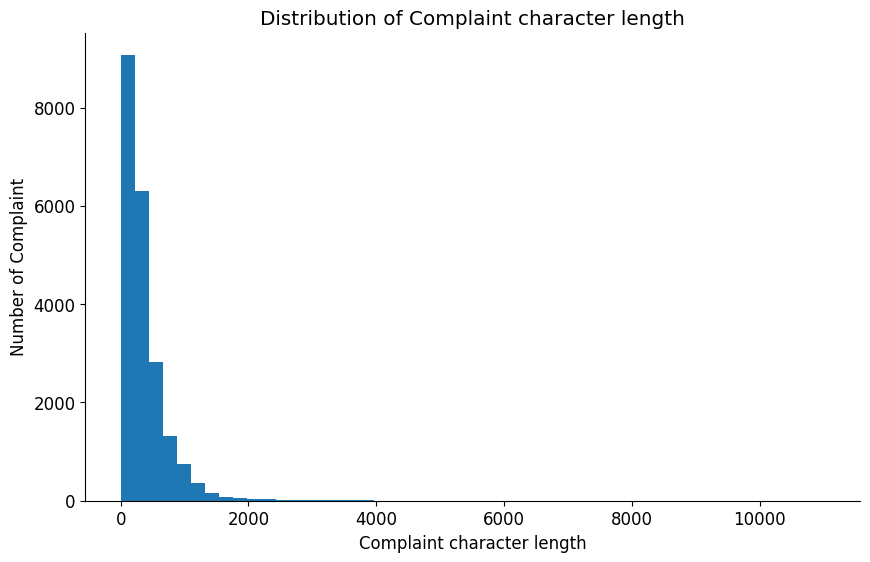

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px
plt.figure(figsize=(10,6))
doc_lens = [len(d) for d in df_clean.complaint_POS_removed]
plt.hist(doc_lens, bins = 50)
plt.title('Distribution of Complaint character length')
plt.ylabel('Number of Complaint')
plt.xlabel('Complaint character length')
sns.despine();

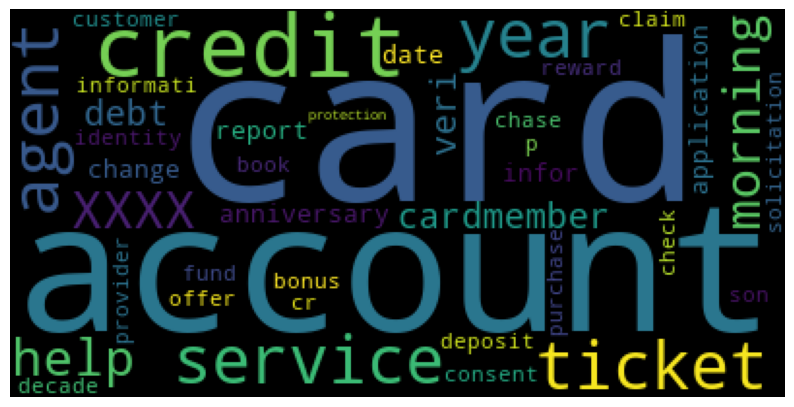

In [295]:
#Using a word cloud find the top 40 words by frequency among all the articles after processing the text

from wordcloud import WordCloud

wordcloud = WordCloud(stopwords=stopwords,max_words=40).generate(str(df_clean.complaint_POS_removed))

print(wordcloud)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [296]:
#Removing -PRON- from the text corpus
df_clean['Complaint_clean'] = df_clean['complaint_POS_removed'].str.replace('-PRON-', '')
df_clean = df_clean.drop(['complaint_POS_removed'],axis = 1)
df_clean

,complaint_text,lemma,category,Complaint_clean
1,Good morning my name is XXXX XXXX and I apprec...,good morning XXXX xxxx I appreciate help stop ...,Debt collection+Credit card debt,morning XXXX help cardmember service debt veri...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,I upgrade XXXX XXXX card XX / XX/2018 tell age...,Credit card or prepaid card+General-purpose cr...,card agent anniversary date change agent infor...
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o...",report application identity consent service cr...
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o...",book ticket offer ticket reward card informati...
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account,son check deposit chase account fund account p...
...,...,...,...,...
78303,After being a Chase Card customer for well ove...,"after Chase Card customer decade , offer multi...",Credit card or prepaid card+General-purpose cr...,customer decade solicitation credit card bonus...
78309,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...","on Wednesday , XX / XX / XXXX I call Chas , xx...",Credit card or prepaid card+General-purpose cr...,provider claim purchase protection benefit XXX...
78310,I am not familiar with XXXX pay and did not un...,I familiar XXXX pay understand great risk prov...,Checking or savings account+Checking account,pay risk consumer bank app year trust mobile b...
78311,I have had flawless credit for 30 yrs. I've ha...,I flawless credit 30 yr . I Chase credit card ...,Credit card or prepaid card+General-purpose cr...,credit yr credit card problem transfer life ex...


## Here are the top unigrams,bigrams and trigrams by frequency among all the complaints after processing the text. ‘

'Credit’, ‘debt’, ‘bank’, ‘loan’ and ‘mortgage’ are some of the top words which makes sense given the focus of the complaints.

In [297]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pprint import pprint
def get_top_n_words(corpus, n=None):
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]
common_words = get_top_n_words(df_clean['Complaint_clean'].values.astype('U'), 50)
df2 = pd.DataFrame(common_words, columns = ['unigram' , 'count'])

fig = go.Figure([go.Bar(x=df2['unigram'], y=df2['count'])])
fig.update_layout(title=go.layout.Title(text="Top 50 unigrams in the Complaint text after removing stop words and lemmatization"))
fig.show()

In [298]:
df2.head(10)

,unigram,count
0,account,44093
1,xxxx,38284
2,credit,30773
3,card,27535
4,payment,20719
5,time,15923
6,charge,15090
7,bank,14926
8,day,13092
9,money,11592


In [299]:
def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]
common_words = get_top_n_bigram(df_clean['Complaint_clean'].values.astype('U'), 30)
df3 = pd.DataFrame(common_words, columns = ['bigram' , 'count'])
fig = go.Figure([go.Bar(x=df3['bigram'], y=df3['count'])])
fig.update_layout(title=go.layout.Title(text="Top 30 bigrams in the Complaint text after removing stop words and lemmatization"))
fig.show()

In [303]:
df3.head(5)

,bigram,count
0,credit card,11278
1,xxxx xxxx,7826
2,credit report,3738
3,customer service,2598
4,account account,2532


In [304]:
def get_top_n_trigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]
common_words = get_top_n_trigram(df_clean['Complaint_clean'].values.astype('U'), 30)
df4 = pd.DataFrame(common_words, columns = ['trigram' , 'count'])
fig = go.Figure([go.Bar(x=df4['trigram'], y=df4['count'])])
fig.update_layout(title=go.layout.Title(text="Top 30 trigrams in the Complaint text"))
fig.show()

In [305]:
df4.head(5)

,trigram,count
0,xxxx xxxx xxxx,2375
1,credit card account,1041
2,credit card company,887
3,charge credit card,520
4,credit card credit,489


##

In [140]:
#All masked texts has been removed
df_clean

,complaint_text,lemma,category,Complaint_clean
1,Good morning my name is XXXX XXXX and I apprec...,good morning XXXX xxxx I appreciate help stop ...,Debt collection+Credit card debt,morning XXXX help cardmember service debt veri...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,I upgrade XXXX XXXX card XX / XX/2018 tell age...,Credit card or prepaid card+General-purpose cr...,card agent anniversary date change agent infor...
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o...",report application identity consent service cr...
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o...",book ticket offer ticket reward card informati...
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account,son check deposit chase account fund account p...
...,...,...,...,...
78303,After being a Chase Card customer for well ove...,"after Chase Card customer decade , offer multi...",Credit card or prepaid card+General-purpose cr...,customer decade solicitation credit card bonus...
78309,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...","on Wednesday , XX / XX / XXXX I call Chas , xx...",Credit card or prepaid card+General-purpose cr...,provider claim purchase protection benefit XXX...
78310,I am not familiar with XXXX pay and did not un...,I familiar XXXX pay understand great risk prov...,Checking or savings account+Checking account,pay risk consumer bank app year trust mobile b...
78311,I have had flawless credit for 30 yrs. I've ha...,I flawless credit 30 yr . I Chase credit card ...,Credit card or prepaid card+General-purpose cr...,credit yr credit card problem transfer life ex...


## Lets now convert the raw texts to a matrix of TF-IDF features

max_df is used for removing terms that appear too frequently, also known as "corpus-specific stop words"
max_df = 0.95 means "ignore terms that appear in more than 95% of the complaints"

min_df is used for removing terms that appear too infrequently
min_df = 2 means "ignore terms that appear in less than 2 complaints"

In [141]:
tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')

## Create a document term matrix using fit_transform

The contents of a document term matrix are tuples of (complaint_id,token_id) tf-idf score:
The tuples that are not there have a tf-idf score of 0

In [142]:
dtm = tfidf.fit_transform(df_clean['Complaint_clean'])

## NMF

Non-Negative Matrix Factorization (NMF) is an unsupervised technique so there are no labeling of topics that the model will be trained on. The way it works is that, NMF decomposes (or factorizes) high-dimensional vectors into a lower-dimensional representation. These lower-dimensional vectors are non-negative which also means their coefficients are non-negative.

In [143]:
from sklearn.decomposition import NMF

## Coherence Model to select best number of Topics
With the Coherence Model we will see how to automatically select the best number of topics. 


In [144]:
import warnings
warnings.filterwarnings("ignore")
from gensim.corpora.dictionary import Dictionary
from gensim.models.nmf import Nmf
from gensim.models.coherencemodel import CoherenceModel
from operator import itemgetter
# Use Gensim's NMF to get the best num of topics via coherence score
texts = df_clean['Complaint_clean']
dataset = [d.split() for d in texts]

# Create a dictionary
# In gensim a dictionary is a mapping between words and their integer id
dictionary = Dictionary(dataset)

# Filter out extremes to limit the number of features
dictionary.filter_extremes(
    no_below=3,
    no_above=0.85,
    keep_n=5000
)

# Create the bag-of-words format (list of (token_id, token_count))
corpus = [dictionary.doc2bow(text) for text in dataset]

# Create a list of the topic numbers we want to try
topic_nums = list(np.arange(5, 10, 1))

# Run the nmf model and calculate the coherence score
# for each number of topics
coherence_scores = []

for num in topic_nums:
    nmf = Nmf(
        corpus=corpus,
        num_topics=num,
        id2word=dictionary,
        chunksize=2000,
        passes=5,
        kappa=.1,
        minimum_probability=0.01,
        w_max_iter=300,
        w_stop_condition=0.0001,
        h_max_iter=100,
        h_stop_condition=0.001,
        eval_every=10,
        normalize=True,
        random_state=42
    )
    
    # Run the coherence model to get the score
    cm = CoherenceModel(
        model=nmf,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    coherence_scores.append(round(cm.get_coherence(), 5))

# Get the number of topics with the highest coherence score
scores = list(zip(topic_nums, coherence_scores))
best_num_topics = sorted(scores, key=itemgetter(1), reverse=True)[0][0]

print(best_num_topics)

5


## Manual Topic Modeling
With the CoherenceModel we got the best number of topics=5.The hard work is already done at this point so all we need to do is run the model.

The only parameter that is required is the number of components i.e. the number of topics we want. This is the most crucial step in the whole topic modeling process and will greatly affect how good your final topics are.

In [145]:
nmf_model = NMF(n_components=5,random_state=40)

In [146]:
nmf_model.fit(dtm)
len(tfidf.get_feature_names_out())

6307

In [147]:
#Print the top word of a sample component
single_topic = nmf_model.components_[0]
single_topic.argsort()
top_word_indices = single_topic.argsort()[-10:]
for index in top_word_indices:
    print(tfidf.get_feature_names_out()[index])

transfer
chase
branch
day
fund
deposit
money
bank
check
account


In [59]:
#Print Top15 words for each of the topics
for index,topic in enumerate(nmf_model.components_):
    print(f'THE TOP 15 WORDS FOR TOPIC #{index}')
    print([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-15:]])
    print('\n')

THE TOP 15 WORDS FOR TOPIC #0
['transfer', 'claim', 'checking', 'transaction', 'business', 'number', 'day', 'branch', 'deposit', 'chase', 'fund', 'money', 'check', 'bank', 'account']


THE TOP 15 WORDS FOR TOPIC #1
['year', 'balance', 'letter', 'application', 'debt', 'information', 'limit', 'company', 'score', 'account', 'chase', 'inquiry', 'report', 'card', 'credit']


THE TOP 15 WORDS FOR TOPIC #2
['mortgage', 'year', 'chase', 'account', 'credit', 'pay', 'date', 'auto', 'time', 'day', 'statement', 'fee', 'month', 'balance', 'payment']


THE TOP 15 WORDS FOR TOPIC #3
['company', 'refund', 'statement', 'time', 'service', 'purchase', 'claim', 'fraud', 'merchant', 'chase', 'dispute', 'transaction', 'fee', 'card', 'charge']


THE TOP 15 WORDS FOR TOPIC #4
['sale', 'foreclosure', 'house', 'bank', 'document', 'time', 'rate', 'letter', 'year', 'property', 'chase', 'modification', 'home', 'mortgage', 'loan']




In [148]:
#Creating the best topic for each complaint
topic_results = nmf_model.transform(dtm)
topic_results[0].round(2)
topic_results[0].argmax()
topic_results.argmax(axis=1)

array([4, 4, 1, ..., 4, 2, 2], dtype=int64)

In [149]:
#Assign the best topic to each of the cmplaints in Topic Column
df_clean['Topic'] = topic_results.argmax(axis=1)

In [150]:
df_clean.head()

,complaint_text,lemma,category,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,good morning XXXX xxxx I appreciate help stop ...,Debt collection+Credit card debt,morning XXXX help cardmember service debt veri...,4
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,I upgrade XXXX XXXX card XX / XX/2018 tell age...,Credit card or prepaid card+General-purpose cr...,card agent anniversary date change agent infor...,4
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o...",report application identity consent service cr...,1
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o...",book ticket offer ticket reward card informati...,1
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account,son check deposit chase account fund account p...,0


In [151]:
#Print the first 5 Complaint for each of the Topics
df_dc=df_clean.groupby('Topic').head(5)
df_dc.sort_values('Topic')

,complaint_text,lemma,category,Complaint_clean,Topic
27,I opened an account with chase bank on XXXX an...,I open account chase bank XXXX code XXXX bonus...,Checking or savings account+Checking account,account chase bank code bonus term account dep...,0
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account,son check deposit chase account fund account p...,0
17,With out notice J.P. Morgan Chase restricted m...,with notice J.P. Morgan Chase restrict account...,Checking or savings account+Checking account,notice account debit card branch customer serv...,0
42,My card went missing and i didnt realize it un...,"my card go missing not realize today , check e...",Checking or savings account+Checking account,card today email deposit money bank account,0
35,I opened the saving account for the {$25.00} b...,I open save account { $ 25.00 } bonus . I supp...,Checking or savings account+Savings account,save account bonus bonus auto transfer check t...,0
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o...",report application identity consent service cr...,1
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o...",book ticket offer ticket reward card informati...,1
15,Can you please remove inquiry,can remove inquiry,"Credit reporting, credit repair services, or o...",inquiry,1
23,I have a Chase credit card which is incorrectl...,I Chase credit card incorrectly report datum c...,Credit card or prepaid card+General-purpose cr...,credit card datum credit report company issue,1
26,I have reached out to XXXX several times in at...,I reach XXXX time attempt fraudulent inquiry r...,"Credit reporting, credit repair services, or o...",time attempt inquiry remove contact creditor p...,1


In [158]:
#Create the dictionary of Topic names and Topics
Topic_names = {0:"Bank Account services",1:"Credit card or prepaid card", 2:"Others",3:"Theft/Dispute Reporting",4:"Mortgage/Loan"}

In [162]:
df_bk=df_dc

In [163]:
#Replace Topics with Topic Names
df_bk['Topic'] = df_bk['Topic'].map(Topic_names)

In [164]:
df_bk

,complaint_text,lemma,category,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,good morning XXXX xxxx I appreciate help stop ...,Debt collection+Credit card debt,morning XXXX help cardmember service debt veri...,Mortgage/Loan
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,I upgrade XXXX XXXX card XX / XX/2018 tell age...,Credit card or prepaid card+General-purpose cr...,card agent anniversary date change agent infor...,Mortgage/Loan
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o...",report application identity consent service cr...,Credit card or prepaid card
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o...",book ticket offer ticket reward card informati...,Credit card or prepaid card
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account,son check deposit chase account fund account p...,Bank Account services
15,Can you please remove inquiry,can remove inquiry,"Credit reporting, credit repair services, or o...",inquiry,Credit card or prepaid card
17,With out notice J.P. Morgan Chase restricted m...,with notice J.P. Morgan Chase restrict account...,Checking or savings account+Checking account,notice account debit card branch customer serv...,Bank Account services
20,"During the summer months, I experience a decli...","during summer month , I experience decline inc...",Vehicle loan or lease+Loan,summer month decline income employment month p...,Others
21,"On XXXX XX/XX/2019, I made a {$300.00} payment...","on XXXX XX / XX/2019 , I { $ 300.00 } payment ...","Money transfer, virtual currency, or money ser...",payment retailer website scam website confirma...,Mortgage/Loan
23,I have a Chase credit card which is incorrectl...,I Chase credit card incorrectly report datum c...,Credit card or prepaid card+General-purpose cr...,credit card datum credit report company issue,Credit card or prepaid card


In [165]:
df_clean =df_bk

## Supervised model to predict any new complaints to the relevant Topics.

We have seen how to get the topics of the complaints, now in the below section we will see how we can use them to classify any new complaints.

Since we will be using supervised learning technique we have to convert the topic names to numbers(numpy arrays only understand numbers)

In [166]:
#Topic_names = {"Bank Account services":0,"Credit card or prepaid card":1,"Others":2,"Theft/Dispute Reporting":3,"Mortgage/Loan":4}
#df_clean['Topic'] = df_clean['Topic'].map(Topic_names)

In [167]:
df_clean

,complaint_text,lemma,category,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,good morning XXXX xxxx I appreciate help stop ...,Debt collection+Credit card debt,morning XXXX help cardmember service debt veri...,Mortgage/Loan
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,I upgrade XXXX XXXX card XX / XX/2018 tell age...,Credit card or prepaid card+General-purpose cr...,card agent anniversary date change agent infor...,Mortgage/Loan
10,Chase Card was reported on XX/XX/2019. However...,"Chase Card report XX / XX/2019 . however , fra...","Credit reporting, credit repair services, or o...",report application identity consent service cr...,Credit card or prepaid card
11,"On XX/XX/2018, while trying to book a XXXX XX...","on XX / XX/2018 , try book XXXX xxxx ticke...","Credit reporting, credit repair services, or o...",book ticket offer ticket reward card informati...,Credit card or prepaid card
14,my grand son give me check for {$1600.00} i de...,grand son check { $ 1600.00 } deposit chase ac...,Checking or savings account+Checking account,son check deposit chase account fund account p...,Bank Account services
15,Can you please remove inquiry,can remove inquiry,"Credit reporting, credit repair services, or o...",inquiry,Credit card or prepaid card
17,With out notice J.P. Morgan Chase restricted m...,with notice J.P. Morgan Chase restrict account...,Checking or savings account+Checking account,notice account debit card branch customer serv...,Bank Account services
20,"During the summer months, I experience a decli...","during summer month , I experience decline inc...",Vehicle loan or lease+Loan,summer month decline income employment month p...,Others
21,"On XXXX XX/XX/2019, I made a {$300.00} payment...","on XXXX XX / XX/2019 , I { $ 300.00 } payment ...","Money transfer, virtual currency, or money ser...",payment retailer website scam website confirma...,Mortgage/Loan
23,I have a Chase credit card which is incorrectl...,I Chase credit card incorrectly report datum c...,Credit card or prepaid card+General-purpose cr...,credit card datum credit report company issue,Credit card or prepaid card


In [168]:
training_data=df_clean[["complaint_text","Topic"]]

In [169]:
training_data

,complaint_text,Topic
1,Good morning my name is XXXX XXXX and I apprec...,Mortgage/Loan
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Mortgage/Loan
10,Chase Card was reported on XX/XX/2019. However...,Credit card or prepaid card
11,"On XX/XX/2018, while trying to book a XXXX XX...",Credit card or prepaid card
14,my grand son give me check for {$1600.00} i de...,Bank Account services
15,Can you please remove inquiry,Credit card or prepaid card
17,With out notice J.P. Morgan Chase restricted m...,Bank Account services
20,"During the summer months, I experience a decli...",Others
21,"On XXXX XX/XX/2019, I made a {$300.00} payment...",Mortgage/Loan
23,I have a Chase credit card which is incorrectl...,Credit card or prepaid card


In [ ]:
Topic_names = {0:"Bank Account services",1:"Credit card or prepaid card", 2:"Others",3:"Theft/Dispute Reporting",4:"Mortgage/Loan"}

In [176]:
## Reverse topic names mapping for supervised learning

reverse_topic_mapping = {
    'Bank Account services' :0,
    'Credit card or prepaid card':1,
    'Others':2,
    'Theft/Dispute Reporting':3,
    'Mortgage/Loan':4
}
#Replace Topics with Topic Names
training_data['Topic'] = training_data['Topic'].map(reverse_topic_mapping)
training_data.head()

,complaint_text,Topic
1,Good morning my name is XXXX XXXX and I apprec...,4
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,4
10,Chase Card was reported on XX/XX/2019. However...,1
11,"On XX/XX/2018, while trying to book a XXXX XX...",1
14,my grand son give me check for {$1600.00} i de...,0


## **X - Y split**

In [212]:
# x - y  split
X = training_data.complaint_text
y = training_data.Topic

In [213]:
#Write your code to get the Vector count 

# Fit transform the X
count_vect = CountVectorizer()
X_vect = count_vect.fit_transform(X)

In [215]:
from sklearn.feature_extraction.text import TfidfTransformer
#Write your code here to transform the word vector to tf-idf
#Fit transform word vector to TF-IDF
tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_vect)


**Train-test Split**

In [216]:
from sklearn.model_selection import train_test_split
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.25, random_state=40, stratify=y)

In [217]:
# Write your code here to build any 3 models and evaluate them using the required metrics

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_fscore_support

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [219]:
# utlity function to display the model report

def display_classification_report(model,metric):
    
    y_train_pred_proba = model.predict_proba(X_train)
    y_test_pred_proba = model.predict_proba(X_test)
    roc_auc_score_train = round(roc_auc_score(y_train, y_train_pred_proba,average='weighted',multi_class='ovr'),2)
    roc_auc_score_test = round(roc_auc_score(y_test, y_test_pred_proba,average='weighted',multi_class='ovr'),2)
    print("ROC AUC Score Train:", roc_auc_score_train)
    print("ROC AUC Score Test:", roc_auc_score_test)
    metric.append(roc_auc_score_train)
    metric.append(roc_auc_score_test)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
  
    precision_train,recall_train,fscore_train,support_train=precision_recall_fscore_support(y_train,y_train_pred,average='weighted')
    precision_test,recall_test,fscore_test,support_test=precision_recall_fscore_support(y_test,y_test_pred,average='weighted')
    
    acc_score_train = round(accuracy_score(y_train,y_train_pred),2)
    acc_score_test = round(accuracy_score(y_test,y_test_pred),2)
    
    metric.append(acc_score_train)
    metric.append(acc_score_test)
    metric.append(round(precision_train,2))
    metric.append(round(precision_test,2))
    metric.append(round(recall_train,2))
    metric.append(round(recall_test,2))
    metric.append(round(fscore_train,2))
    metric.append(round(fscore_test,2))
    
    print('Train Accuracy :',acc_score_train)
    print('Test Accuracy :',acc_score_test)
        
    model_report_train = classification_report(y_train,y_train_pred)
    model_report_test = classification_report(y_test,y_test_pred)
    
    print('Classification Report for Train:\n',model_report_train)
    print('Classification Report for Test:\n',model_report_test)


    # Plot the confusion matrix
    fig, ax = plt.subplots(figsize=(12, 8))
    # Create the confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    cmp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    cmp.plot(ax=ax)
    plt.xticks(rotation=80)

    plt.show();

ROC AUC Score Train: 1.0
ROC AUC Score Test: 0.7
Train Accuracy : 0.94
Test Accuracy : 0.43
Classification Report for Train:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.93      0.94        18
weighted avg       0.96      0.94      0.94        18

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       1.00      1.00      1.00         1
           2       0.50      1.00      0.67         1
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         2

    accuracy              

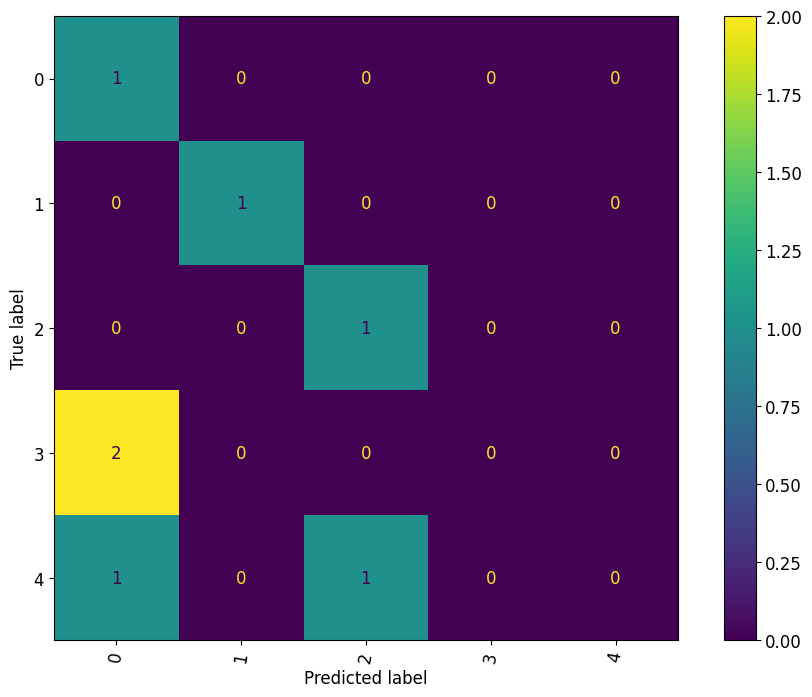

In [218]:
# Multinomial Naive Bayes Classification

# create MNB model object
mnb = MultinomialNB()
# fit model
mnb.fit(X_train, y_train)
# display classification report
metric1=[]
display_classification_report(mnb,metric1)

**Logistic Regression Classification**

ROC AUC Score Train: 1.0
ROC AUC Score Test: 0.61
Train Accuracy : 1.0
Test Accuracy : 0.43
Classification Report for Train:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       1.00      1.00      1.00         1
           2       0.50      1.00      0.67         1
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         2

    accuracy              

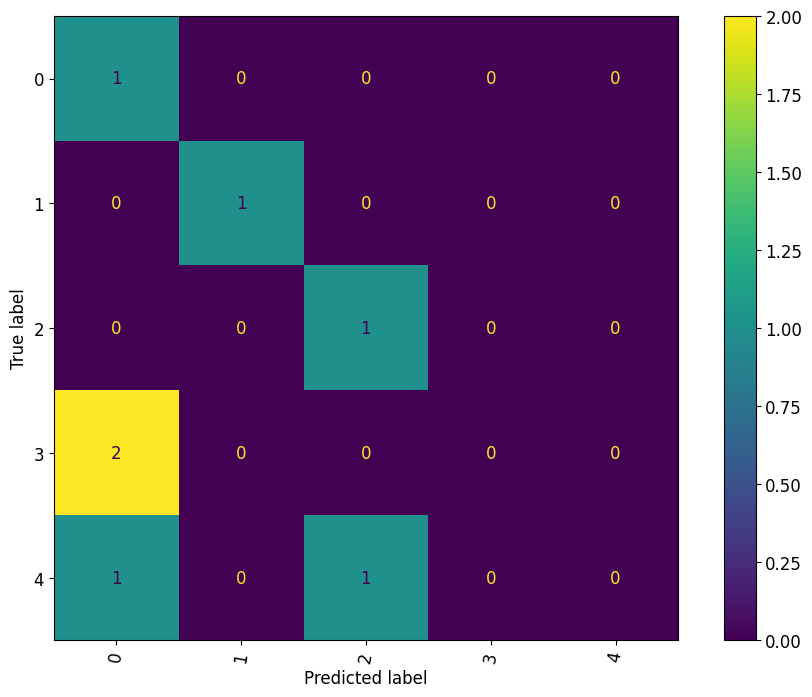

In [221]:
# Logistic Regression Classification
log_reg = LogisticRegression(random_state=40,solver='liblinear')
# fit model
log_reg.fit(X_train,y_train)
# display classification report
metric2=[]
display_classification_report(log_reg,metric2)

**Decision Tree Classification**

ROC AUC Score Train: 1.0
ROC AUC Score Test: 0.5
Train Accuracy : 1.0
Test Accuracy : 0.14
Classification Report for Train:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.25      1.00      0.40         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         2

    accuracy               

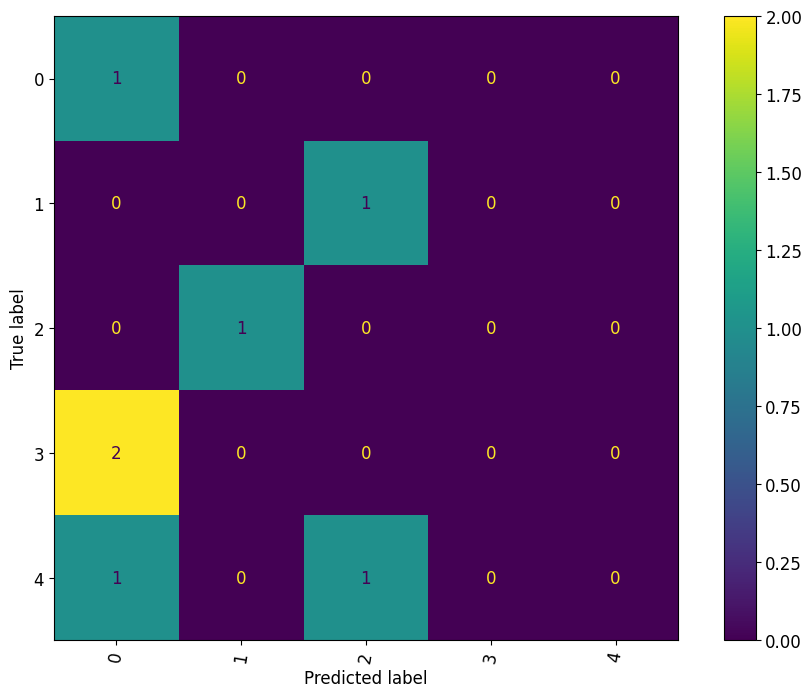

In [222]:
# Decision Tree Classification
dtc = DecisionTreeClassifier(random_state=40)
# fit model
dtc.fit(X_train,y_train)
# Decision Tree Classification Report
metric3=[]
display_classification_report(dtc,metric3)

## **Random Forest Classification**

OOB SCORE : 0.1111111111111111
ROC AUC Score Train: 1.0
ROC AUC Score Test: 0.68
Train Accuracy : 1.0
Test Accuracy : 0.29
Classification Report for Train:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Classification Report for Test:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       1.00      0.50      0.67         2
           4       0.25      0.50      0.33       

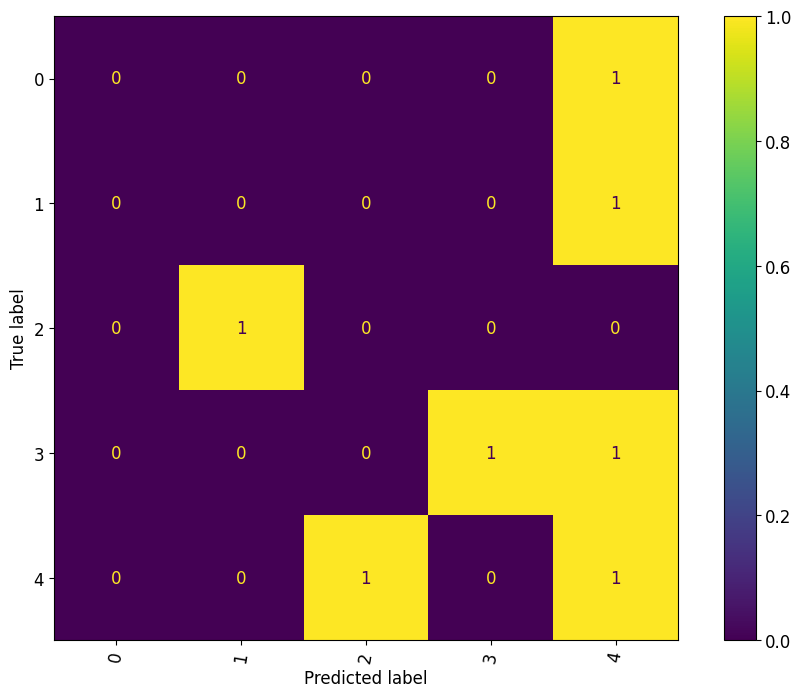

In [223]:
# Random Forest Classification

rf = RandomForestClassifier(n_estimators = 500,random_state=40, n_jobs = -1,oob_score=True)
# fit model
rf.fit(X_train,y_train)

# oob score
print('OOB SCORE :',rf.oob_score_)

# Random Forest Classification Report
metric4=[]
display_classification_report(rf,metric4)

In [225]:
table = {'Metric': ['ROC_AUC Score(Train)','ROC_AUC Score(Test)',
                    'Accuracy(Train)','Accuracy(Test)',
                    'Precision(Train)','Precision(Test)',
                    'Recall(Train)','Recall(Test)',
                    'F1-Score(Train)','F1-Score(Test)'
                   ], 
        'Multinomial Naive Bayes': metric1
        }

mnb_metric = pd.DataFrame(table ,columns = ['Metric', 'Multinomial Naive Bayes'] )
log_metric = pd.Series(metric2, name = 'Logistic Regression')
dtc_metric = pd.Series(metric3, name = 'Decision Tree Classifier')
rfc_metric = pd.Series(metric4, name = 'Random Forest Classifier')
#grid_mnb_metric = pd.Series(metric5, name = 'Multinomial Naive Bayes with GridSearchCV')
#grid_log_metric = pd.Series(metric6, name = 'Logistic Regression with GridSearchCV')
#grid_dtc_metric = pd.Series(metric7, name = 'Decision Tree Classifier with GridSearchCV')
#grid_rfc_metric = pd.Series(metric8, name = 'Random Forest Classifier with GridSearchCV')

final_metric = pd.concat([mnb_metric,log_metric,dtc_metric,rfc_metric], axis = 1)

#final_metric = pd.concat([mnb_metric,log_metric,dtc_metric,rfc_metric,
#                         grid_mnb_metric,grid_log_metric,grid_dtc_metric,grid_rfc_metric], axis = 1)

final_metric

,Metric,Multinomial Naive Bayes,Logistic Regression,Decision Tree Classifier,Random Forest Classifier
0,ROC_AUC Score(Train),1.00,1.00,1.00,1.00
1,ROC_AUC Score(Test),0.70,0.61,0.50,0.68
2,Accuracy(Train),0.94,1.00,1.00,1.00
3,Accuracy(Test),0.43,0.43,0.14,0.29
4,Precision(Train),0.96,1.00,1.00,1.00
5,Precision(Test),0.25,0.25,0.04,0.36
6,Recall(Train),0.94,1.00,1.00,1.00
7,Recall(Test),0.43,0.43,0.14,0.29
8,F1-Score(Train),0.94,1.00,1.00,1.00
9,F1-Score(Test),0.30,0.30,0.06,0.29


In [232]:
mnb_metric

,Metric,Multinomial Naive Bayes
0,ROC_AUC Score(Train),1.00
1,ROC_AUC Score(Test),0.70
2,Accuracy(Train),0.94
3,Accuracy(Test),0.43
4,Precision(Train),0.96
5,Precision(Test),0.25
6,Recall(Train),0.94
7,Recall(Test),0.43
8,F1-Score(Train),0.94
9,F1-Score(Test),0.30


In [234]:
dtc_metric

0    1.00
1    0.50
2    1.00
3    0.14
4    1.00
5    0.04
6    1.00
7    0.14
8    1.00
9    0.06
Name: Decision Tree Classifier, dtype: float64

In [233]:
log_metric

0    1.00
1    0.61
2    1.00
3    0.43
4    1.00
5    0.25
6    1.00
7    0.43
8    1.00
9    0.30
Name: Logistic Regression, dtype: float64

### **Complaint Prediction using the best model above**

In [226]:
# raw complaint text
test_complaint= 'I tried to make a transaction at a supermarket retail store, using my chase \
debit/atm card, but the transaction was declined. I am still able to withdraw money out of an \
ATM machine using the same debit card. Please resolve this issue.'

In [227]:
# vectorize and tf-idf tranform
test = count_vect.transform([test_complaint])
test_tfidf = tfidf_transformer.transform(test)

In [228]:
# predict
prediction=mnb.predict(test_tfidf)
prediction

array([1], dtype=int64)

In [ ]:
Topic_mapping = {0:"Bank Account services",1:"Credit card or prepaid card", 2:"Others",3:"Theft/Dispute Reporting",4:"Mortgage/Loan"}

In [231]:
Topic_names[prediction[0]]

'Credit card or prepaid card'